# **⏳ Umbral en el tiempo**

En el notebook 04, el umbral de la política se eligió con **CV aleatoria**: ahí el óptimo del modelo final es 0,20, igual al teórico de la matriz de costos. Pero la validación out-of-time mostró una tensión: prediciendo las tres últimas semanas, un umbral de 0,15 ganaba entre +0,5 y +1,6 puntos, y cerca del umbral el modelo subestimaba el fraude ponderado por monto.

Ese resultado no se podía usar para cambiar el umbral, porque esas semanas eran la evaluación. Aquí el umbral se elige **como se haría en producción**, solo con el pasado y sin CV aleatoria:

1. **Predicciones forward**: para cada semana, el pipeline productivo se entrena con todo lo anterior y predice esa semana.
2. **Elección**: el umbral se elige con las predicciones forward de las semanas del 25/03, 01/04 y 08/04.
3. **Evaluación**: la última semana (15/04 al 21/04), que no interviene en la elección, compara ese umbral con 0,20.

Cada comparación se hace también con las predicciones de la CV aleatoria del notebook 04 **en las mismas filas**, para separar el efecto del esquema de validación de la dificultad de cada semana. El modelo es el final (sin `perfil_onp`, hiperparámetros del notebook 04); aquí no se ajusta nada más que el umbral.

## **📚 Librerías**

In [1]:
# Librerías para manipulación de datos
import pandas as pd
import numpy as np

# Mostrar varias tablas en una misma celda
from IPython.display import display

# Librerías de visualización
import plotly.express as px
import plotly.io as pio

# Módulos del proyecto: datos, pipeline productivo y función de ganancia
from fraude_shipping.features import load_data, make_folds
from fraude_shipping.production.pipeline import THRESHOLD, FraudPipeline
from fraude_shipping.profit import THRESHOLDS, compute_profit, profit_curve

In [2]:
# Gráficos interactivos en el editor y PNG estático para GitHub y el informe
pio.renderers.default = 'plotly_mimetype+png'
pio.templates.default = 'plotly_white'

COLOR_PRINCIPAL = '#2a78d6'
COLOR_REFERENCIA = '#898781'

# Semanas (de miércoles a martes) con predicción forward: las tres primeras eligen el umbral y la última lo evalúa
SEMANAS_ELECCION = ['2020-03-25', '2020-04-01', '2020-04-08']
SEMANA_EVALUACION = '2020-04-15'
# Misma partición de la CV aleatoria que validó el modelo final en el notebook 04
SEMILLA_VALIDACION = 7
REMUESTRAS_BOOTSTRAP = 1000
SEMILLA_BOOTSTRAP = 42

In [3]:
# Ganancia, calibración cerca del umbral y bootstrap de la diferencia entre dos umbrales


def ganancia_pct_maxima(fraude, monto, probabilidad, umbral):
    """Ganancia de aprobar si la probabilidad es menor al umbral, en % de la ganancia máxima."""
    ganancia_maxima = compute_profit(fraude, monto, fraude == 0)
    return compute_profit(fraude, monto, np.asarray(probabilidad) < umbral) / ganancia_maxima * 100


def umbral_optimo(fraude, monto, probabilidad):
    """Umbral de la grilla que maximiza la ganancia."""
    curva = profit_curve(fraude, monto, probabilidad)
    return curva.loc[curva['ganancia'].idxmax(), 'umbral']


def calibracion_franja(datos_franja, columna_probabilidad, umbral_inferior, umbral_superior):
    """Predicho y observado en una franja de probabilidad, por conteo y ponderados por monto."""
    franja = datos_franja[datos_franja[columna_probabilidad].between(umbral_inferior, umbral_superior, inclusive='left')]
    return pd.Series({
        'transacciones': len(franja),
        'predicho': franja[columna_probabilidad].mean(),
        'observado': franja['fraude'].mean(),
        'predicho_por_monto': np.average(franja[columna_probabilidad], weights=franja['monto']),
        'observado_por_monto': np.average(franja['fraude'], weights=franja['monto']),
    })


def bootstrap_diferencia_umbrales(datos_semana, probabilidad, umbral_a, umbral_b):
    """Diferencia de ganancia entre dos umbrales en remuestras bootstrap: media, IC95 y probabilidad de que gane el primero."""
    generador = np.random.default_rng(SEMILLA_BOOTSTRAP)
    fraude, monto = datos_semana['fraude'].to_numpy(), datos_semana['monto'].to_numpy()
    diferencias = []
    for _ in range(REMUESTRAS_BOOTSTRAP):
        indices = generador.integers(0, len(fraude), len(fraude))
        diferencias.append(
            ganancia_pct_maxima(fraude[indices], monto[indices], probabilidad[indices], umbral_a)
            - ganancia_pct_maxima(fraude[indices], monto[indices], probabilidad[indices], umbral_b)
        )
    diferencias = np.array(diferencias)
    return pd.Series({
        'diferencia_media': diferencias.mean(),
        'ic95_inferior': np.percentile(diferencias, 2.5),
        'ic95_superior': np.percentile(diferencias, 97.5),
        'probabilidad_gana_a': (diferencias > 0).mean(),
    })

## **🔢 Datos**

In [4]:
datos = load_data('../data/raw/dataset.csv')
datos['semana'] = datos['fecha'].dt.to_period('W-TUE').dt.start_time.dt.strftime('%Y-%m-%d')
datos.groupby('semana').agg(transacciones=('fraude', 'size'), tasa_fraude=('fraude', 'mean')).round(4)

,transacciones,tasa_fraude
semana,,
2020-03-04,11116,0.0457
2020-03-11,24727,0.0478
2020-03-18,24581,0.0483
2020-03-25,16537,0.0605
2020-04-01,20282,0.0564
2020-04-08,23771,0.0522
2020-04-15,28986,0.0427


La primera semana está incompleta (empieza el domingo 8/03), y las dos primeras semanas completas dejan poco pasado para entrenar. Por eso la predicción forward empieza el 25/03, con 60.000 transacciones de entrenamiento.

## **🔮 Predicciones forward y CV aleatoria**

In [5]:
# Forward: para cada semana, el pipeline productivo se entrena con todo lo anterior y predice esa semana
semanas_forward = SEMANAS_ELECCION + [SEMANA_EVALUACION]
datos['probabilidad_forward'] = np.nan
for semana in semanas_forward:
    pasado = datos[datos['fecha'] < semana]
    filas_semana = datos['semana'] == semana
    datos.loc[filas_semana, 'probabilidad_forward'] = FraudPipeline().fit(pasado).predict_proba(datos[filas_semana])

In [6]:
# CV aleatoria del notebook 04 (semilla 7): cada transacción la predice un modelo entrenado con el resto, incluido el futuro
datos['probabilidad_cv'] = np.nan
for indices_train, indices_validacion in make_folds(datos['fraude'], seed=SEMILLA_VALIDACION):
    pipeline = FraudPipeline().fit(datos.iloc[indices_train])
    datos.iloc[indices_validacion, datos.columns.get_loc('probabilidad_cv')] = pipeline.predict_proba(datos.iloc[indices_validacion])

datos_forward = datos[datos['semana'].isin(semanas_forward)]
print(f"Ganancia de la CV aleatoria completa con umbral {THRESHOLD}: "
      f"{ganancia_pct_maxima(datos['fraude'], datos['monto'], datos['probabilidad_cv'], THRESHOLD):.2f}%")

Ganancia de la CV aleatoria completa con umbral 0.2: 78.89%


## **📅 Variación entre semanas**

In [7]:
# Ganancia de cada semana con el umbral de la política: forward, CV aleatoria en las mismas filas y aprobar todo


def resumen_semana(datos_semana):
    """Ganancia de la semana según cómo se predijo, y la referencia de aprobar todo."""
    fraude, monto = datos_semana['fraude'], datos_semana['monto']
    return pd.Series({
        'tasa_fraude': fraude.mean() * 100,
        'forward': ganancia_pct_maxima(fraude, monto, datos_semana['probabilidad_forward'], THRESHOLD),
        'cv_aleatoria': ganancia_pct_maxima(fraude, monto, datos_semana['probabilidad_cv'], THRESHOLD),
        'aprobar_todo': ganancia_pct_maxima(fraude, monto, np.zeros(len(datos_semana)), THRESHOLD),
    })


ganancia_semanal = datos_forward.groupby('semana').apply(resumen_semana)
ganancia_semanal['diferencia_vs_cv'] = ganancia_semanal['forward'] - ganancia_semanal['cv_aleatoria']
display(ganancia_semanal.round(2))
ganancia_semanal[['forward', 'cv_aleatoria', 'aprobar_todo']].agg(['mean', 'std', 'min', 'max']).round(2)

,tasa_fraude,forward,cv_aleatoria,aprobar_todo,diferencia_vs_cv
semana,,,,,
2020-03-25,6.05,75.31,78.70,57.44,-3.39
2020-04-01,5.64,73.72,73.65,54.54,0.07
2020-04-08,5.22,77.11,78.12,59.43,-1.02
2020-04-15,4.27,79.46,79.85,67.14,-0.39


,forward,cv_aleatoria,aprobar_todo
mean,76.40,77.58,59.64
std,2.46,2.72,5.39
min,73.72,73.65,54.54
max,79.46,79.85,67.14


**💡 Hallazgos**

- **La ganancia varía entre semanas más que entre folds.** Prediciendo cada semana con el pasado, el modelo da **73,7% a 79,5%** (media 76,4%, desvío 2,5 puntos), frente al ±1,3 entre los folds de la CV aleatoria, que son intercambiables por construcción.
- **Esa variación es de las semanas, no del esquema de validación.** En las mismas filas, la CV aleatoria varía igual (73,7% a 79,9%, desvío 2,7), y aprobar todo va de 54,5% a 67,1%. Cada semana tiene su propia tasa de fraude (de 6,1% a 4,3%) y su propia dificultad.
- La semana del 25/03 es la única donde forward pierde bastante frente a la CV (−3,4 puntos): su modelo se entrenó con solo 60.000 transacciones. Con más historia, la diferencia queda entre −1,0 y +0,1.
- Para producción, la expectativa no es "78,9% ± 1,3" sino **~77% en promedio, entre 74% y 80% según la semana**. Las alertas de monitoreo deben usar la variación semanal, no la de los folds.

## **🎚️ Elección del umbral con el pasado**

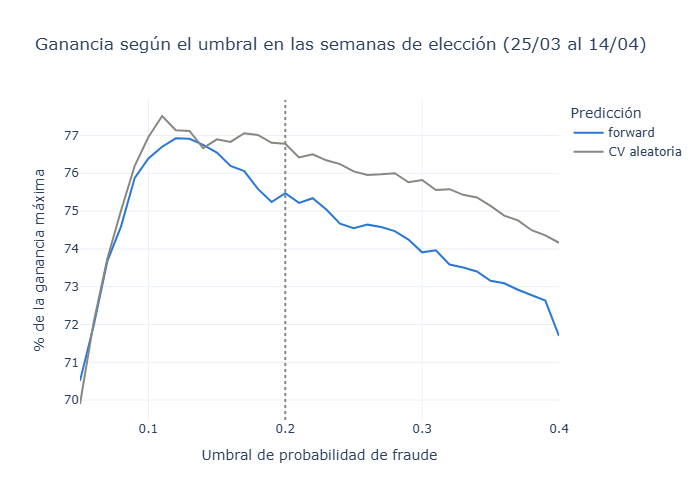

In [8]:
# Curva de ganancia en las semanas de elección, con las predicciones forward y con las de la CV aleatoria en las mismas filas
datos_eleccion = datos_forward[datos_forward['semana'].isin(SEMANAS_ELECCION)]
curvas = pd.concat([
    pd.DataFrame({
        'umbral': THRESHOLDS,
        'ganancia_pct_maxima': [
            ganancia_pct_maxima(datos_eleccion['fraude'], datos_eleccion['monto'], datos_eleccion[columna], umbral)
            for umbral in THRESHOLDS
        ],
        'prediccion': nombre,
    })
    for columna, nombre in [('probabilidad_forward', 'forward'), ('probabilidad_cv', 'CV aleatoria')]
], ignore_index=True)

fig = px.line(
    curvas.query('0.05 <= umbral <= 0.40'),
    x='umbral',
    y='ganancia_pct_maxima',
    color='prediccion',
    color_discrete_map={'forward': COLOR_PRINCIPAL, 'CV aleatoria': COLOR_REFERENCIA},
    labels={'umbral': 'Umbral de probabilidad de fraude', 'ganancia_pct_maxima': '% de la ganancia máxima', 'prediccion': 'Predicción'},
    title='Ganancia según el umbral en las semanas de elección (25/03 al 14/04)',
)
fig.add_vline(x=THRESHOLD, line_dash='dot', line_color=COLOR_REFERENCIA)
fig.show()

In [9]:
# Umbral óptimo por semana y en las tres semanas juntas, con cada tipo de predicción
filas = []
for nombre, datos_grupo in [*datos_eleccion.groupby('semana'), ('tres semanas', datos_eleccion)]:
    fila = {'semana': nombre}
    for columna, prediccion in [('probabilidad_forward', 'forward'), ('probabilidad_cv', 'cv')]:
        umbral = umbral_optimo(datos_grupo['fraude'], datos_grupo['monto'], datos_grupo[columna])
        fila[f'umbral_optimo_{prediccion}'] = umbral
        fila[f'ganancia_optimo_{prediccion}'] = ganancia_pct_maxima(datos_grupo['fraude'], datos_grupo['monto'], datos_grupo[columna], umbral)
        fila[f'ganancia_{THRESHOLD}_{prediccion}'] = ganancia_pct_maxima(datos_grupo['fraude'], datos_grupo['monto'], datos_grupo[columna], THRESHOLD)
    filas.append(fila)

umbrales_eleccion = pd.DataFrame(filas).set_index('semana')
umbral_forward = umbrales_eleccion.loc['tres semanas', 'umbral_optimo_forward']
print(f'Umbral elegido con las predicciones forward: {umbral_forward:.2f}')
umbrales_eleccion.round(3)

Umbral elegido con las predicciones forward: 0.12


,umbral_optimo_forward,ganancia_optimo_forward,ganancia_0.2_forward,umbral_optimo_cv,ganancia_optimo_cv,ganancia_0.2_cv
semana,,,,,,
2020-03-25,0.15,76.534,75.309,0.18,78.913,78.700
2020-04-01,0.14,75.352,73.722,0.11,76.228,73.648
2020-04-08,0.12,79.083,77.106,0.18,78.815,78.125
tres semanas,0.12,76.924,75.473,0.11,77.515,76.783


**💡 Hallazgos**

- **Elegido con las predicciones forward de las tres semanas, el umbral es 0,12**, y en esas semanas gana 1,5 puntos sobre 0,20 (76,9% frente a 75,5%).
- **Pero con la CV aleatoria, en las mismas filas, el óptimo también es bajo (0,11).** Estas semanas, con más fraude que el promedio, favorecen umbrales bajos con cualquier esquema: no es solo un efecto de predecir el futuro. En el dataset completo, la CV aleatoria da 0,20.
- **El óptimo de cada semana es inestable**: 0,15, 0,14 y 0,12 con forward, y 0,18, 0,11 y 0,18 con la CV. La curva es plana y el máximo se mueve con la composición de cada semana.
- Por encima de 0,20, la curva forward cae más rápido que la de la CV: al predecir el futuro, aprobar más cuesta más.

## **📐 Calibración cerca del umbral**

In [10]:
# Predicho frente a observado en la franja de decisión (0,10–0,20), en las semanas de elección
pd.DataFrame({
    'forward': calibracion_franja(datos_eleccion, 'probabilidad_forward', 0.10, THRESHOLD),
    'cv_aleatoria': calibracion_franja(datos_eleccion, 'probabilidad_cv', 0.10, THRESHOLD),
}).T.round(3)

,transacciones,predicho,observado,predicho_por_monto,observado_por_monto
forward,3350.0,0.139,0.172,0.141,0.221
cv_aleatoria,3441.0,0.140,0.162,0.141,0.204


**💡 Hallazgos**

- **Cerca del umbral, el modelo subestima el fraude con los dos esquemas.** En la franja 0,10–0,20 de estas semanas, forward predice 0,14 y se observa 0,17 (0,22 ponderado por monto). La CV aleatoria, en las mismas filas, también subestima (0,16 observado, 0,20 por monto).
- La subestimación forward es algo mayor, lo que explica que su curva caiga más rápido por encima de 0,20. Pero la mayor parte ya aparece en la CV aleatoria: en estas semanas el fraude es más alto que el promedio con que se entrenó el modelo.

## **🧪 Evaluación en la última semana**

In [11]:
# Última semana: umbral elegido con el pasado frente al de la política, con las predicciones forward
datos_evaluacion = datos_forward[datos_forward['semana'] == SEMANA_EVALUACION]
probabilidad_evaluacion = datos_evaluacion['probabilidad_forward'].to_numpy()
umbrales_comparados = {'politica': THRESHOLD, 'elegido_forward': umbral_forward, 'optimo_a_posteriori': umbral_optimo(
    datos_evaluacion['fraude'], datos_evaluacion['monto'], probabilidad_evaluacion)}

display(pd.DataFrame([
    {'umbral': nombre, 'valor': umbral,
     'ganancia_pct_maxima': ganancia_pct_maxima(datos_evaluacion['fraude'], datos_evaluacion['monto'], probabilidad_evaluacion, umbral)}
    for nombre, umbral in umbrales_comparados.items()
]).set_index('umbral').round(3))
bootstrap_diferencia_umbrales(datos_evaluacion, probabilidad_evaluacion, umbral_forward, THRESHOLD).round(3)

,valor,ganancia_pct_maxima
umbral,,
politica,0.20,79.458
elegido_forward,0.12,79.534
optimo_a_posteriori,0.17,80.577


diferencia_media       0.087
ic95_inferior         -1.664
ic95_superior          2.272
probabilidad_gana_a    0.508
dtype: float64

**💡 Hallazgos**

- **En la última semana, el umbral elegido con el pasado (0,12) no se distingue del de la política**: 79,5% frente a 79,5% (+0,09 puntos, IC95 de −1,7 a +2,3; gana en el 51% de las remuestras). Con una semana de evaluación, la prueba no tiene potencia para distinguir umbrales vecinos.
- El óptimo a posteriori de esa semana es 0,17 (80,6%), distinto del elegido con las semanas anteriores (0,12): con una semana de etiquetas no se puede acertar el óptimo de la siguiente.

## **🏁 Conclusión**

- **Elegir el umbral con el pasado, sin CV aleatoria, no permite distinguir otro mejor.** El esquema forward elige 0,12, y en la semana siguiente no se distingue de 0,20: con una semana, la prueba no tiene potencia. La evidencia temporal a favor de un umbral más bajo existe (las semanas previas lo prefieren y el modelo subestima cerca del umbral), pero no se traslada a la semana siguiente.
- **Se mantiene 0,20**: el umbral teórico de la matriz de costos, el óptimo con la CV aleatoria en el dataset completo, y no hay que estimarlo: no depende de qué semanas se usen para elegirlo.
- **La causa es la tasa base, no el esquema de validación.** Las semanas con más fraude prefieren umbrales bajos también con la CV aleatoria, y cerca del umbral el modelo subestima con los dos. Es un cambio en la tasa base: en producción no se persigue el umbral, se corrigen las probabilidades por la tasa vigente, `p′ = p·a / (p·a + (1−p)·b), con a = π′/π y b = (1−π′)/(1−π)`, o se recalibran con etiquetas maduras, y el umbral queda en 0,20.
- **La incertidumbre que hay que comunicar es la semanal**: ~77% en promedio, entre 74% y 80% según la semana, no el ±1,3 entre folds.